In [17]:
import numpy as np
import matplotlib.pyplot as plt

In [18]:
x_data = np.array([0.079, 0.637, 1.345, 2.095, 2.782])
y_data = np.array([-4.308, -0.739, 1.697, 4.208, 6.203])

In [19]:
def lagrange_polynomial(x_val, x, y):
    n = len(x)
    result = 0.0
    for i in range(n):
        p = 1.0
        for j in range(n):
            if i != j:
                p *= (x_val - x[j]) / (x[i] - x[j])
        result += p * y[i]
    return result

In [20]:
def divided_differences(x, y):
    n = len(y)
    coef = np.zeros([n, n])
    coef[:, 0] = y
    for j in range(1, n):
        for i in range(n - j):
            coef[i][j] = (coef[i + 1][j - 1] - coef[i][j - 1]) / (x[i + j] - x[i])
    return coef[0, :]

In [21]:
def newton_polynomial(x_val, x, y):
    coef = divided_differences(x, y)
    n = len(x)
    result = coef[0]
    p = 1.0
    for i in range(1, n):
        p *= (x_val - x[i - 1])
        result += coef[i] * p
    return result

In [22]:
def linear_spline(x_val, x, y):
    for i in range(len(x) - 1):
        if x[i] <= x_val <= x[i + 1]:
            A = np.array([[x[i], 1], [x[i + 1], 1]])
            B = np.array([y[i], y[i + 1]])
            coeffs = np.linalg.solve(A, B)
            return coeffs[0] * x_val + coeffs[1]
    return None

In [23]:
def quadratic_spline(x_val, x, y):
    for i in range(0, len(x) - 2, 2):
        if x[i] <= x_val <= x[i + 2]:
            A = np.array([
                [x[i]**2, x[i], 1],
                [x[i+1]**2, x[i+1], 1],
                [x[i+2]**2, x[i+2], 1]
            ])
            B = np.array([y[i], y[i+1], y[i+2]])
            coeffs = np.linalg.solve(A, B)
            return coeffs[0] * x_val**2 + coeffs[1] * x_val + coeffs[2]
    return None

Значение в точке x1+x2 (1.982):
Многочлен Лагранжа: 3.8098
Полином Ньютона: 3.8098


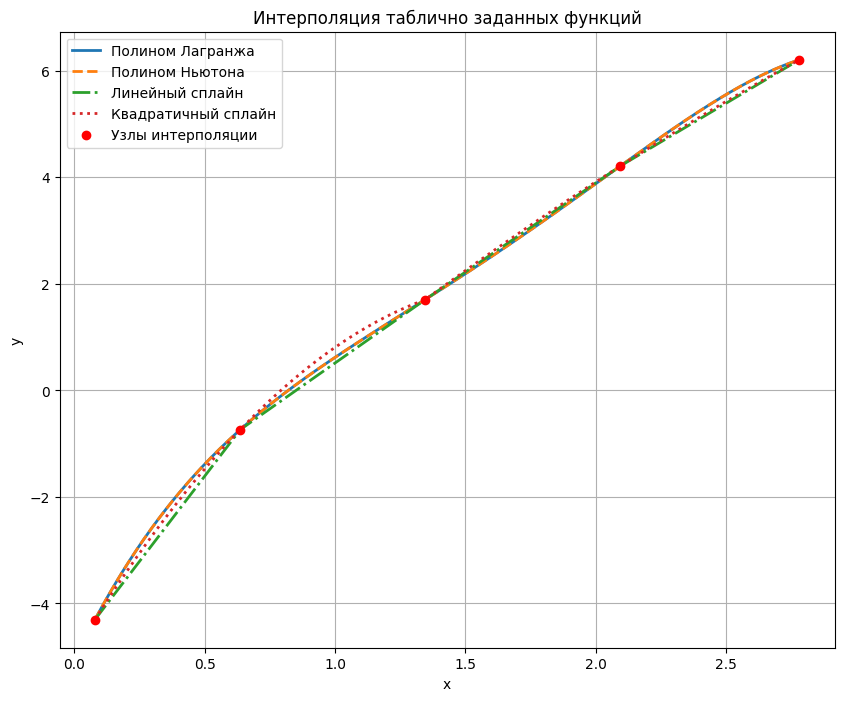

In [24]:
x_target = x_data[1] + x_data[2]

print(f"Значение в точке x1+x2 ({x_target:.3f}):")
print(f"Многочлен Лагранжа: {lagrange_polynomial(x_target, x_data, y_data):.4f}")
print(f"Полином Ньютона: {newton_polynomial(x_target, x_data, y_data):.4f}")

x_plot = np.linspace(x_data[0], x_data[-1], 500)
y_lagrange = [lagrange_polynomial(xi, x_data, y_data) for xi in x_plot]
y_newton = [newton_polynomial(xi, x_data, y_data) for xi in x_plot]
y_linear = [linear_spline(xi, x_data, y_data) for xi in x_plot]
y_quadratic = [quadratic_spline(xi, x_data, y_data) for xi in x_plot]

plt.figure(figsize=(10, 8))

plt.plot(x_plot, y_lagrange, label='Полином Лагранжа', linestyle='-', linewidth=2)
plt.plot(x_plot, y_newton, label='Полином Ньютона', linestyle='--', linewidth=2)
plt.plot(x_plot, y_linear, label='Линейный сплайн', linestyle='-.', linewidth=2)
plt.plot(x_plot, y_quadratic, label='Квадратичный сплайн', linestyle=':', linewidth=2)

plt.scatter(x_data, y_data, color='red', zorder=5, label='Узлы интерполяции')

plt.title('Интерполяция таблично заданных функций')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True)
plt.legend()
plt.show()